In [1]:
import json
import os
import pandas as pd
import seaborn as sns
sns.set(rc={'figure.figsize':(6,3)})
sns.set_style("white")
import matplotlib.pyplot as plt


# cleanup data

In [2]:
dq = pd.read_csv("ratings/_questionnaire.csv")

users_to_be_excluded = set([47,8])

# exclude non-valid runs
dq["valid"] = dq["user_ID"].apply(lambda x: x not in users_to_be_excluded)
dq = dq[dq["valid"]]
print(dq.columns)

def extract_answers(x):
    data = pd.Series(json.loads(x["answers_json"]))
    uid = x["user_ID"]
    data["user_ID"] = uid
    return data

dq = dq.apply(extract_answers, axis=1)

dq

Index(['user_ID', 'answers_json', 'valid'], dtype='object')


,user_age_range,user_gender,user_perception_tests,user_eye_quality,user_room_quality,user_computer_type,user_test_origin,screen_size,browser_agent,user_ID
0,30 to 39,Male,Yes,Good,Alone in a Quiet Room,Laptop,steve s run,1920x968,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,1
1,30 to 39,Male,No,Good,Some Noise and Distractions,Phone,Friend,485x941,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,2
2,30 to 39,Male,No,Good,Some Noise and Distractions,Laptop,friend,1912x954,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,6
3,18 to 24,Male,Yes,Excellent,Some Noise and Distractions,Laptop,friend,1280x585,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,7
5,25 to 29,Female,No,Excellent,Alone in a Quiet Room,Desktop,clickworker test,1858x879,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,9
...,...,...,...,...,...,...,...,...,...,...
66,50 to 59,Female,No,Good,Alone in a Quiet Room,Laptop,Internet,1280x688,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,81
67,30 to 39,Female,Yes,Excellent,Some Noise and Distractions,Laptop,clickworker.de,1366x647,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,82
68,30 to 39,Female,Yes,Excellent,Alone in a Quiet Room,Tablet,Clickworker,820x1052,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,83
69,30 to 39,Female,No,Excellent,Alone in a Quiet Room,Desktop,Clickworker,1920x911,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,84


In [3]:
dr = pd.read_csv("ratings/_ratings.csv")
dr

,user_ID,stimuli_ID,stimuli_file,rating_type,rating,timestamp
0,1,-1,NaN,user_registered,-1,2026-01-12 15:38:51 141098
1,1,536,./stimuli/mayfair_IMG_7753.jpg,range_image_appeal,4,2026-01-12 15:40:07 802754
2,1,536,./stimuli/mayfair_IMG_7753.jpg,range_image_quality,4,2026-01-12 15:40:07 802754
3,1,536,./stimuli/mayfair_IMG_7753.jpg,range_realism,2,2026-01-12 15:40:07 802754
4,1,536,./stimuli/mayfair_IMG_7753.jpg,ww,1920,2026-01-12 15:40:07 802754
...,...,...,...,...,...,...
70175,36,400,./stimuli/lark_IMG_3995.jpg,quality_meta,-1,2026-01-15 11:32:24 047901
70176,36,400,./stimuli/lark_IMG_3995.jpg,pi,1,2026-01-15 11:32:24 047901
70177,36,-1,NaN,user_done,-1,2026-01-15 11:32:24 383391
70178,8,-1,NaN,user_done,-1,2026-01-15 13:00:42 192842


In [4]:
counts = dr[dr["rating_type"] == "range_image_appeal"].groupby(by="user_ID").count().reset_index()
counts

,user_ID,stimuli_ID,stimuli_file,rating_type,rating,timestamp
0,1,150,150,150,150,150
1,6,138,138,138,138,138
2,7,150,150,150,150,150
3,8,150,150,150,150,150
4,9,89,89,89,89,89
5,10,150,150,150,150,150
6,11,150,150,150,150,150
7,12,150,150,150,150,150
8,13,150,150,150,150,150
9,14,150,150,150,150,150


In [5]:
valid_users = set(counts[counts["stimuli_file"] >= 150]["user_ID"].values) - users_to_be_excluded
valid_users

{np.int64(1),
 np.int64(7),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(18),
 np.int64(19),
 np.int64(21),
 np.int64(22),
 np.int64(26),
 np.int64(28),
 np.int64(29),
 np.int64(30),
 np.int64(32),
 np.int64(33),
 np.int64(34),
 np.int64(36),
 np.int64(37),
 np.int64(39),
 np.int64(40),
 np.int64(43),
 np.int64(44),
 np.int64(45),
 np.int64(46),
 np.int64(48),
 np.int64(49),
 np.int64(50),
 np.int64(51),
 np.int64(52),
 np.int64(54),
 np.int64(55),
 np.int64(56),
 np.int64(59),
 np.int64(61),
 np.int64(66),
 np.int64(70),
 np.int64(71),
 np.int64(72),
 np.int64(74),
 np.int64(78),
 np.int64(81),
 np.int64(82),
 np.int64(83),
 np.int64(84),
 np.int64(85)}

In [6]:
dq["valid"] = dq["user_ID"].apply(lambda x: x in valid_users)
dq = dq[dq["valid"]].copy()
dq.to_csv("_questionnaire_clean.csv", index=False)
dq.head()

,user_age_range,user_gender,user_perception_tests,user_eye_quality,user_room_quality,user_computer_type,user_test_origin,screen_size,browser_agent,user_ID,valid
0,30 to 39,Male,Yes,Good,Alone in a Quiet Room,Laptop,steve s run,1920x968,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,1,True
3,18 to 24,Male,Yes,Excellent,Some Noise and Distractions,Laptop,friend,1280x585,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,7,True
6,40 to 49,Male,Yes,Good,Alone in a Quiet Room,Desktop,Clickworker Job,2048x1024,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,10,True
7,60 to 69,Male,Yes,Excellent,Alone in a Quiet Room,Desktop,Clickworker,1707x804,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,11,True
8,30 to 39,Female,No,Excellent,Alone in a Quiet Room,Laptop,clickworker,1707x898,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,12,True


In [7]:
dr["valid"] = dr["user_ID"].apply(lambda x: x in valid_users)
dr = dr[dr["valid"]].copy()
dr.to_csv("_ratings_clean.csv", index=False)
dr.head()

,user_ID,stimuli_ID,stimuli_file,rating_type,rating,timestamp,valid
0,1,-1,NaN,user_registered,-1,2026-01-12 15:38:51 141098,True
1,1,536,./stimuli/mayfair_IMG_7753.jpg,range_image_appeal,4,2026-01-12 15:40:07 802754,True
2,1,536,./stimuli/mayfair_IMG_7753.jpg,range_image_quality,4,2026-01-12 15:40:07 802754,True
3,1,536,./stimuli/mayfair_IMG_7753.jpg,range_realism,2,2026-01-12 15:40:07 802754,True
4,1,536,./stimuli/mayfair_IMG_7753.jpg,ww,1920,2026-01-12 15:40:07 802754,True


# evaluate cleaned data

In [8]:
dq = pd.read_csv("_questionnaire_clean.csv")
dq.head()

,user_age_range,user_gender,user_perception_tests,user_eye_quality,user_room_quality,user_computer_type,user_test_origin,screen_size,browser_agent,user_ID,valid
0,30 to 39,Male,Yes,Good,Alone in a Quiet Room,Laptop,steve s run,1920x968,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,1,True
1,18 to 24,Male,Yes,Excellent,Some Noise and Distractions,Laptop,friend,1280x585,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,7,True
2,40 to 49,Male,Yes,Good,Alone in a Quiet Room,Desktop,Clickworker Job,2048x1024,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,10,True
3,60 to 69,Male,Yes,Excellent,Alone in a Quiet Room,Desktop,Clickworker,1707x804,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,11,True
4,30 to 39,Female,No,Excellent,Alone in a Quiet Room,Laptop,clickworker,1707x898,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,12,True


In [9]:
num_users = len(set(dq["user_ID"].values))
print(f"number of users: {num_users}")

number of users: 49


In [10]:
age_group_ordering = sorted(list(set(dq["user_age_range"].values)) , key=lambda x: int(x.split()[0]))
age_group_ordering

['18 to 24', '25 to 29', '30 to 39', '40 to 49', '50 to 59', '60 to 69']

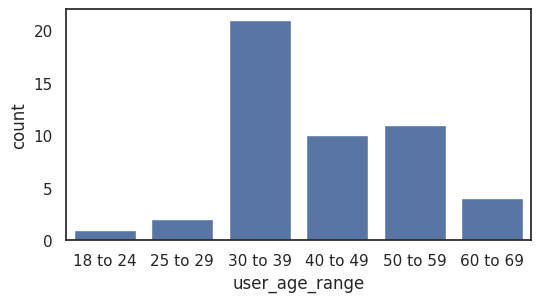

In [11]:
ax = sns.countplot(x="user_age_range", data=dq, order=age_group_ordering)

<Axes: xlabel='screen_size_height', ylabel='Count'>

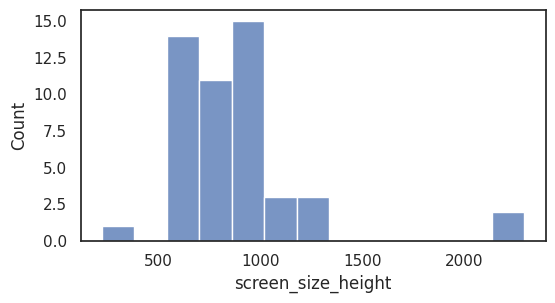

In [12]:
dq["screen_size_height"] = dq["screen_size"].apply(lambda x: int(x.split("x")[1]))
sns.histplot(x="screen_size_height", data=dq)

In [13]:
print(f"""mean display height in px: {dq["screen_size_height"].mean()}""")

mean display height in px: 872.4489795918367


In [14]:
dq.columns

Index(['user_age_range', 'user_gender', 'user_perception_tests',
       'user_eye_quality', 'user_room_quality', 'user_computer_type',
       'user_test_origin', 'screen_size', 'browser_agent', 'user_ID', 'valid',
       'screen_size_height'],
      dtype='object')

In [15]:
dq.groupby(by="user_gender").count().reset_index()

,user_gender,user_age_range,user_perception_tests,user_eye_quality,user_room_quality,user_computer_type,user_test_origin,screen_size,browser_agent,user_ID,valid,screen_size_height
0,Female,22,22,22,22,22,22,22,22,22,22,22
1,Male,26,26,26,26,26,26,26,26,26,26,26
2,Rather not say,1,1,1,1,1,1,1,1,1,1,1


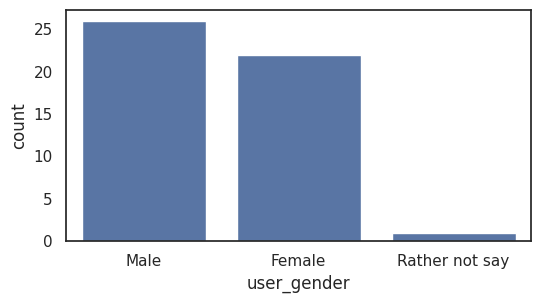

In [16]:
# male vs female
ax = sns.countplot(x="user_gender", data=dq)

Text(0.5, 1.0, 'mean # of ratings per image: 6.8')

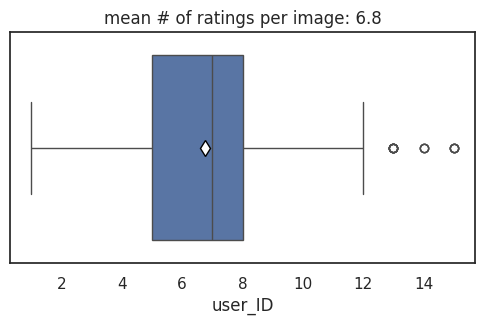

In [17]:
sns.set(rc={'figure.figsize':(6,3)})
sns.set_style("white")

dratings_per_image = dr[dr["rating_type"] == "range_image_appeal"].groupby(by="stimuli_file").count().reset_index()[["stimuli_file", "user_ID"]]

mean_ratings = dratings_per_image["user_ID"].mean()
ax = sns.boxplot(
    x="user_ID", data=dratings_per_image,
    showmeans=True, meanprops={'marker':'d','markerfacecolor':'white','markeredgecolor':'black','markersize':'8'}
)
ax.set_title(f"mean # of ratings per image: {mean_ratings.round(1)}")

In [18]:
dia = dr[dr["rating_type"] == "range_image_appeal"].copy()
dia["filter"] = dia["stimuli_file"].apply(lambda x: os.path.basename(x).split("_")[0])
dia["filter"] = dia["filter"].apply(lambda x: "org" if x == "normal" else x)
dia["base_img"] = dia["stimuli_file"].apply(lambda x: "_".join(os.path.basename(x).split("_")[1:]))
dia["rating"] = dia["rating"].apply(lambda x: int(x))
dia

,user_ID,stimuli_ID,stimuli_file,rating_type,rating,timestamp,valid,filter,base_img
1,1,536,./stimuli/mayfair_IMG_7753.jpg,range_image_appeal,4,2026-01-12 15:40:07 802754,True,mayfair,IMG_7753.jpg
10,1,268,./stimuli/gingham_p26.jpg,range_image_appeal,4,2026-01-12 15:40:18 116008,True,gingham,p26.jpg
19,1,378,./stimuli/hudson_p37.jpg,range_image_appeal,5,2026-01-12 15:40:27 246443,True,hudson,p37.jpg
28,1,719,./stimuli/perpetua_IMG_6255_.jpg,range_image_appeal,4,2026-01-12 15:40:36 695706,True,perpetua,IMG_6255_.jpg
37,1,338,./stimuli/hudson_IMG_7753.jpg,range_image_appeal,4,2026-01-12 15:40:46 593200,True,hudson,IMG_7753.jpg
...,...,...,...,...,...,...,...,...,...
70132,36,1014,./stimuli/xproii_IMG_6010.jpg,range_image_appeal,1,2026-01-15 11:31:35 521731,True,xproii,IMG_6010.jpg
70141,36,205,./stimuli/gingham_IMG_4436.jpg,range_image_appeal,4,2026-01-15 11:31:44 265739,True,gingham,IMG_4436.jpg
70150,36,995,./stimuli/xproii_IMG_4140.jpg,range_image_appeal,4,2026-01-15 11:31:58 875267,True,xproii,IMG_4140.jpg
70159,36,298,./stimuli/hudson_02_IMG_0047.jpg,range_image_appeal,4,2026-01-15 11:32:11 910335,True,hudson,02_IMG_0047.jpg


<Axes: xlabel='rating', ylabel='Count'>

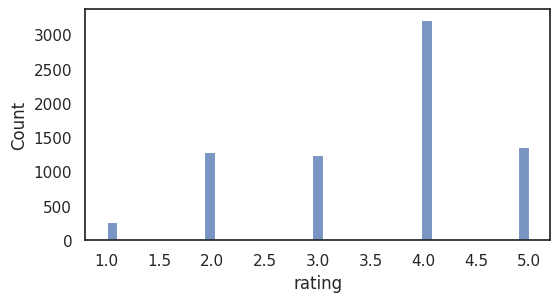

In [19]:
sns.histplot(x="rating", data=dia)

<Axes: xlabel='rating', ylabel='Count'>

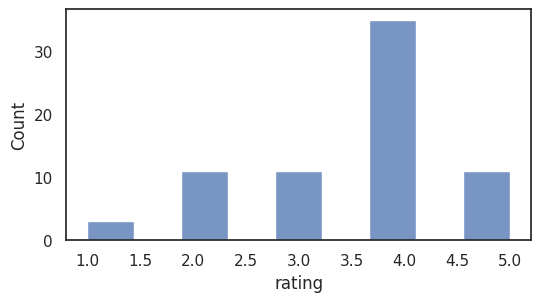

In [20]:
tmp = dia[dia["base_img"] == "p37.jpg"]
sns.histplot(x="rating", data=tmp)

<Axes: xlabel='rating', ylabel='Count'>

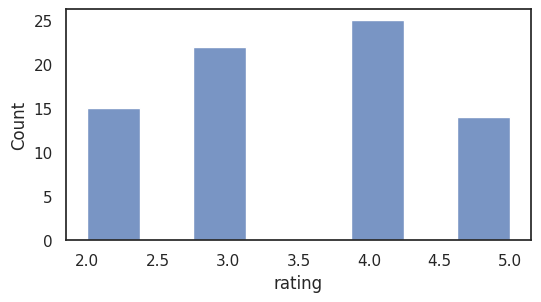

In [21]:
tmp = dia[dia["base_img"] == "p26.jpg"]
sns.histplot(x="rating", data=tmp)

In [22]:
dmean_ia = dia[["stimuli_file", "rating"]].groupby(by=["stimuli_file"]).mean().reset_index()
dmean_ia

,stimuli_file,rating
0,./stimuli/aden_01_IMG_9832.jpg,3.800000
1,./stimuli/aden_02_IMG_0047.jpg,2.875000
2,./stimuli/aden_IMG_1665.jpg,4.200000
3,./stimuli/aden_IMG_3867_4.jpg,2.666667
4,./stimuli/aden_IMG_3995.jpg,2.800000
...,...,...
1084,./stimuli/xproii_p50.jpg,3.250000
1085,./stimuli/xproii_p51.jpg,4.166667
1086,./stimuli/xproii_p52.jpg,3.142857
1087,./stimuli/xproii_p53.jpg,4.000000


<Axes: xlabel='rating', ylabel='Count'>

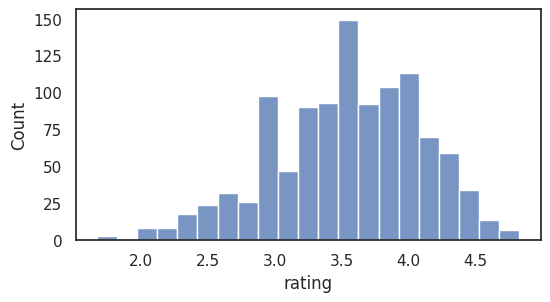

In [23]:
sns.histplot(x="rating", data=dmean_ia)

In [24]:
dmean_ia["filter"] = dmean_ia["stimuli_file"].apply(lambda x: os.path.basename(x).split("_")[0])
dmean_ia["filter"] = dmean_ia["filter"].apply(lambda x: "org" if x == "normal" else x)
dmean_ia["base_img"] = dmean_ia["stimuli_file"].apply(lambda x: "_".join(os.path.basename(x).split("_")[1:]))

<Axes: xlabel='rating', ylabel='base_img'>

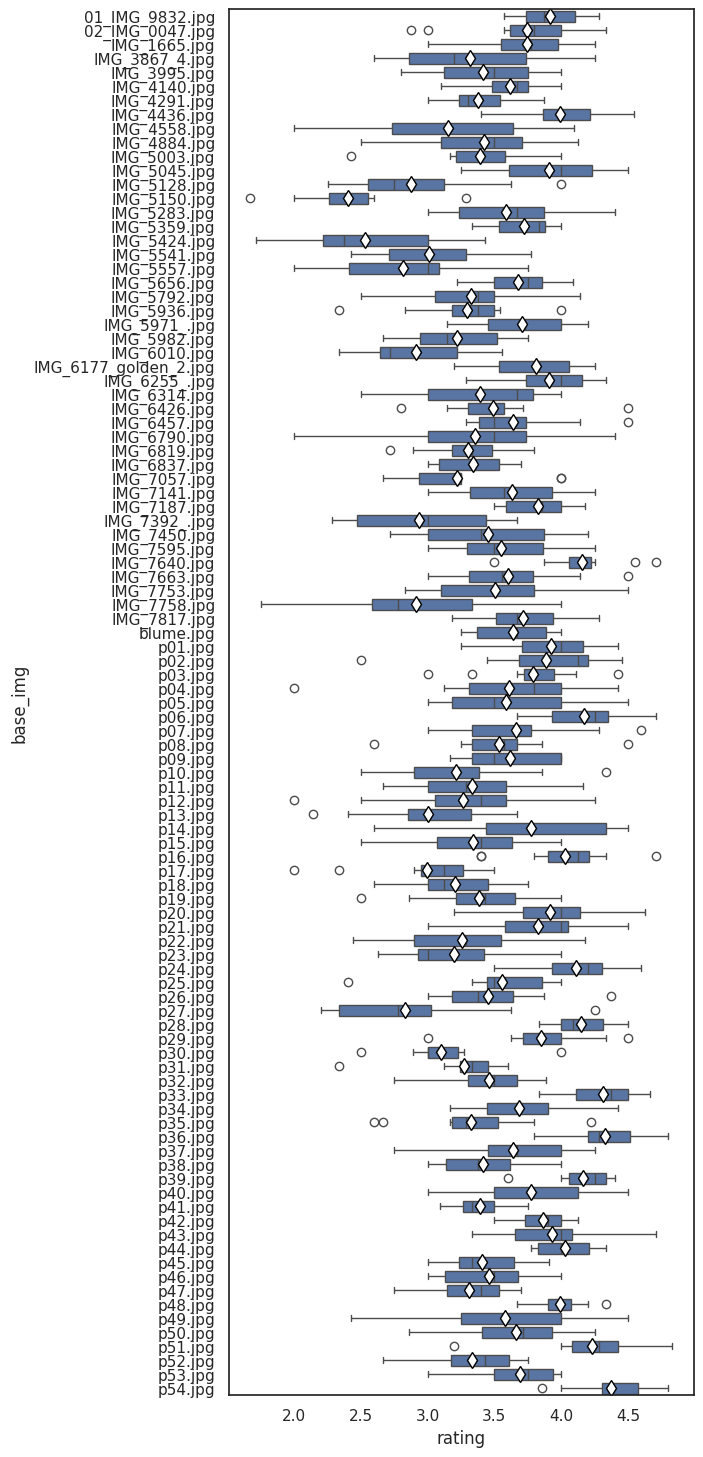

In [25]:
sns.set(rc={'figure.figsize':(6,18)})
sns.set_style("white")

sns.boxplot(
    x="rating", y="base_img", data=dmean_ia,
    showmeans=True, meanprops={'marker':'d','markerfacecolor':'white','markeredgecolor':'black','markersize':'8'}
)

In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

sns.set(rc={'figure.figsize':(6, 48)})
sns.set_style("white")

def skip():
    dheatmap_ia = dmean_ia.pivot(index="base_img", columns="filter", values="rating")
    
    ax = sns.heatmap(dheatmap_ia, annot=False, cbar=True, cmap="Blues", fmt="0.0f", square=True, linewidths=0.5,
        vmin=1, vmax=5,
        cbar_kws={"orientation": "horizontal", "location": "top", 'shrink': 0.4, "pad": 0.1}
    )
    
    for i in range(len(dheatmap_ia)):
        max_col = dheatmap_ia.iloc[i].idxmax()
        j = list(dheatmap_ia.columns).index(max_col)  # Get column index
        
        rect = patches.Rectangle(
            (j, i), 1, 1,
            linewidth=1, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)
    
    
    plt.title("filter ratings in comparison to base image")
    plt.show()


#sns.heatmap(dheatmap_ia)

In [27]:
dmean_ia

,stimuli_file,rating,filter,base_img
0,./stimuli/aden_01_IMG_9832.jpg,3.800000,aden,01_IMG_9832.jpg
1,./stimuli/aden_02_IMG_0047.jpg,2.875000,aden,02_IMG_0047.jpg
2,./stimuli/aden_IMG_1665.jpg,4.200000,aden,IMG_1665.jpg
3,./stimuli/aden_IMG_3867_4.jpg,2.666667,aden,IMG_3867_4.jpg
4,./stimuli/aden_IMG_3995.jpg,2.800000,aden,IMG_3995.jpg
...,...,...,...,...
1084,./stimuli/xproii_p50.jpg,3.250000,xproii,p50.jpg
1085,./stimuli/xproii_p51.jpg,4.166667,xproii,p51.jpg
1086,./stimuli/xproii_p52.jpg,3.142857,xproii,p52.jpg
1087,./stimuli/xproii_p53.jpg,4.000000,xproii,p53.jpg


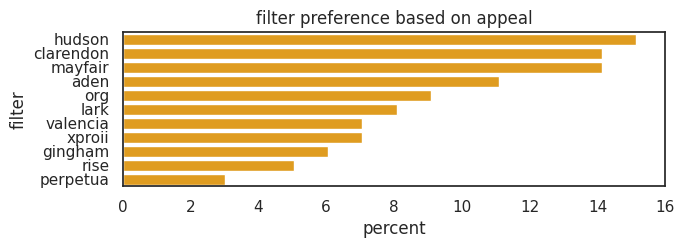

In [28]:
maxrating_per_image = dmean_ia.groupby(by="base_img").apply(lambda x: x[x['rating'] == x['rating'].max()].head(1), include_groups=False).reset_index(drop=True)

sns.set(rc={'figure.figsize':(7,2)})
sns.set_style("white")
ax = sns.countplot(
    y="filter", 
    data=maxrating_per_image, 
    stat="percent",
    order=maxrating_per_image['filter'].value_counts().index,
    color="orange"
)
ax.set_title("filter preference based on appeal")
ax.set_xlim(0,16)
ax.get_figure().savefig("filter_appeal_pref.pdf", bbox_inches='tight')

# TODO: export image +  color it

In [29]:
maxrating_per_image["rating_type"] = "appeal"
pref = maxrating_per_image.copy()
pref


,stimuli_file,rating,filter,rating_type
0,./stimuli/hudson_01_IMG_9832.jpg,4.285714,hudson,appeal
1,./stimuli/hudson_02_IMG_0047.jpg,4.333333,hudson,appeal
2,./stimuli/valencia_IMG_1665.jpg,4.250000,valencia,appeal
3,./stimuli/rise_IMG_3867_4.jpg,4.250000,rise,appeal
4,./stimuli/rise_IMG_3995.jpg,4.000000,rise,appeal
...,...,...,...,...
94,./stimuli/aden_p50.jpg,4.250000,aden,appeal
95,./stimuli/aden_p51.jpg,4.833333,aden,appeal
96,./stimuli/lark_p52.jpg,3.750000,lark,appeal
97,./stimuli/aden_p53.jpg,4.000000,aden,appeal


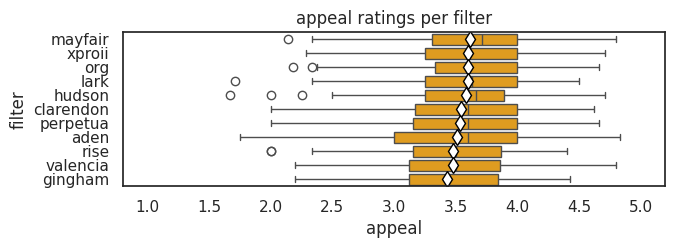

In [30]:
sns.set(rc={'figure.figsize':(7,2)})
sns.set_style("white")
ax = sns.boxplot(
    x="rating", y="filter", data=dmean_ia,
    order=list(
        dmean_ia[["filter", "rating"]].groupby(by=['filter']).mean().sort_values(by="rating", ascending=False).index
    ),
    showmeans=True, meanprops={'marker':'d','markerfacecolor':'white','markeredgecolor':'black','markersize':'8'},
    color="orange"
)
ax.set_xlabel("appeal")
ax.set_xlim(0.8,5.2)
ax.set_title("appeal ratings per filter")
# TODO export this figure + color it

ax.get_figure().savefig("filter_appeal.pdf", bbox_inches='tight')

In [31]:
dmean_ia[["filter", "rating"]].groupby(by=['filter']).mean().sort_values(by="rating").round(2)

,rating
filter,
gingham,3.43
valencia,3.48
rise,3.48
aden,3.51
perpetua,3.53
clarendon,3.54
hudson,3.58
lark,3.60
org,3.60


In [32]:
dmean_ia[["filter", "rating"]].groupby(by=['filter']).mean().sort_values(by="rating", ascending=False)

,rating
filter,
mayfair,3.618574
xproii,3.603758
org,3.598448
lark,3.597516
hudson,3.580330
clarendon,3.539469
perpetua,3.534401
aden,3.512536
rise,3.479026


mean appeal rating: mean_appeal=np.float64(3.54)
std appeal rating: std_appeal=np.float64(0.56)


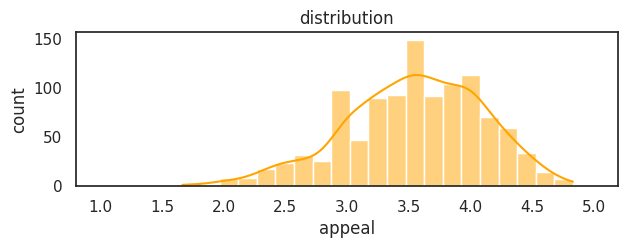

In [33]:
sns.set(rc={'figure.figsize':(7,2)})
sns.set_style("white")
ax = sns.histplot(dmean_ia["rating"], kde=True, color="orange")
ax.set_xlabel("appeal")
ax.set_ylabel("count")
ax.set_xlim(0.8,5.2)
ax.set_title("distribution")
ax.get_figure().savefig("dist_appeal.pdf", bbox_inches='tight')

mean_appeal = dmean_ia["rating"].mean().round(2)
std_appeal = dmean_ia["rating"].std().round(2)

print(f"mean appeal rating: {mean_appeal=}")
print(f"std appeal rating: {std_appeal=}")

In [34]:
dmean_ia.sort_values(by="rating", ascending=False).head(3)


,stimuli_file,rating,filter,base_img
95,./stimuli/aden_p51.jpg,4.833333,aden,p51.jpg
989,./stimuli/valencia_p54.jpg,4.800000,valencia,p54.jpg
575,./stimuli/mayfair_p36.jpg,4.800000,mayfair,p36.jpg


In [35]:
dmean_ia.sort_values(by="rating", ascending=False).iloc[len(dmean_ia) // 2]

stimuli_file    ./stimuli/perpetua_01_IMG_9832.jpg
rating                                    3.571429
filter                                    perpetua
base_img                           01_IMG_9832.jpg
Name: 693, dtype: object

In [36]:
dmean_ia.sort_values(by="rating", ascending=False).tail(3)

,stimuli_file,rating,filter,base_img
42,./stimuli/aden_IMG_7758.jpg,1.750000,aden,IMG_7758.jpg
412,./stimuli/lark_IMG_5424.jpg,1.714286,lark,IMG_5424.jpg
310,./stimuli/hudson_IMG_5150.jpg,1.666667,hudson,IMG_5150.jpg


In [37]:
# quality 

dq = dr[dr["rating_type"] == "range_image_quality"].copy()
dq["filter"] = dq["stimuli_file"].apply(lambda x: os.path.basename(x).split("_")[0])
dq["filter"] = dq["filter"].apply(lambda x: "org" if x == "normal" else x)
dq["base_img"] = dq["stimuli_file"].apply(lambda x: "_".join(os.path.basename(x).split("_")[1:]))
dq["rating"] = dq["rating"].apply(lambda x: int(x))
dq

,user_ID,stimuli_ID,stimuli_file,rating_type,rating,timestamp,valid,filter,base_img
2,1,536,./stimuli/mayfair_IMG_7753.jpg,range_image_quality,4,2026-01-12 15:40:07 802754,True,mayfair,IMG_7753.jpg
11,1,268,./stimuli/gingham_p26.jpg,range_image_quality,3,2026-01-12 15:40:18 116008,True,gingham,p26.jpg
20,1,378,./stimuli/hudson_p37.jpg,range_image_quality,4,2026-01-12 15:40:27 246443,True,hudson,p37.jpg
29,1,719,./stimuli/perpetua_IMG_6255_.jpg,range_image_quality,2,2026-01-12 15:40:36 695706,True,perpetua,IMG_6255_.jpg
38,1,338,./stimuli/hudson_IMG_7753.jpg,range_image_quality,2,2026-01-12 15:40:46 593200,True,hudson,IMG_7753.jpg
...,...,...,...,...,...,...,...,...,...
70133,36,1014,./stimuli/xproii_IMG_6010.jpg,range_image_quality,2,2026-01-15 11:31:35 521731,True,xproii,IMG_6010.jpg
70142,36,205,./stimuli/gingham_IMG_4436.jpg,range_image_quality,5,2026-01-15 11:31:44 265739,True,gingham,IMG_4436.jpg
70151,36,995,./stimuli/xproii_IMG_4140.jpg,range_image_quality,2,2026-01-15 11:31:58 875267,True,xproii,IMG_4140.jpg
70160,36,298,./stimuli/hudson_02_IMG_0047.jpg,range_image_quality,2,2026-01-15 11:32:11 910335,True,hudson,02_IMG_0047.jpg


In [38]:
dmean_iq = dq[["stimuli_file", "rating"]].groupby(by=["stimuli_file"]).mean().reset_index()
dmean_iq

,stimuli_file,rating
0,./stimuli/aden_01_IMG_9832.jpg,3.900000
1,./stimuli/aden_02_IMG_0047.jpg,3.750000
2,./stimuli/aden_IMG_1665.jpg,3.800000
3,./stimuli/aden_IMG_3867_4.jpg,3.166667
4,./stimuli/aden_IMG_3995.jpg,3.000000
...,...,...
1084,./stimuli/xproii_p50.jpg,3.500000
1085,./stimuli/xproii_p51.jpg,3.833333
1086,./stimuli/xproii_p52.jpg,2.857143
1087,./stimuli/xproii_p53.jpg,4.000000


In [39]:
dmean_iq["filter"] = dmean_iq["stimuli_file"].apply(lambda x: os.path.basename(x).split("_")[0])
dmean_iq["filter"] = dmean_iq["filter"].apply(lambda x: "org" if x == "normal" else x)
dmean_iq["base_img"] = dmean_iq["stimuli_file"].apply(lambda x: "_".join(os.path.basename(x).split("_")[1:]))

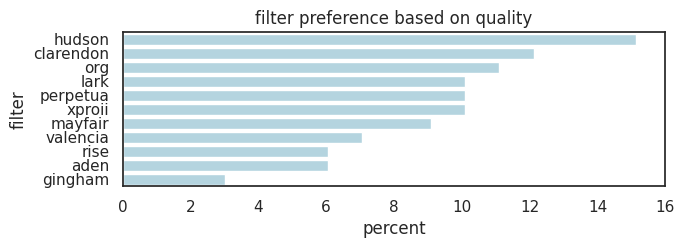

In [40]:
maxrating_per_image = dmean_iq.groupby(by="base_img").apply(lambda x: x[x['rating'] == x['rating'].max()].head(1), include_groups=False).reset_index(drop=True)

sns.set(rc={'figure.figsize':(7,2)})
sns.set_style("white")
ax = sns.countplot(
    y="filter", 
    data=maxrating_per_image, 
    stat="percent",
    order=maxrating_per_image['filter'].value_counts().index,
    color="lightblue"
)
ax.set_xlim(0,16)
ax.set_title("filter preference based on quality")

ax.get_figure().savefig("filter_quality_pref.pdf", bbox_inches='tight')

In [41]:
maxrating_per_image["rating_type"] = "quality"
maxrating_per_image

,stimuli_file,rating,filter,rating_type
0,./stimuli/hudson_01_IMG_9832.jpg,4.428571,hudson,quality
1,./stimuli/perpetua_02_IMG_0047.jpg,4.250000,perpetua,quality
2,./stimuli/valencia_IMG_1665.jpg,4.000000,valencia,quality
3,./stimuli/rise_IMG_3867_4.jpg,4.250000,rise,quality
4,./stimuli/xproii_IMG_3995.jpg,4.500000,xproii,quality
...,...,...,...,...
94,./stimuli/lark_p50.jpg,4.333333,lark,quality
95,./stimuli/aden_p51.jpg,4.666667,aden,quality
96,./stimuli/aden_p52.jpg,3.750000,aden,quality
97,./stimuli/valencia_p53.jpg,4.500000,valencia,quality


In [42]:
pref = pd.concat([pref, maxrating_per_image.copy()], ignore_index=True)
pref

,stimuli_file,rating,filter,rating_type
0,./stimuli/hudson_01_IMG_9832.jpg,4.285714,hudson,appeal
1,./stimuli/hudson_02_IMG_0047.jpg,4.333333,hudson,appeal
2,./stimuli/valencia_IMG_1665.jpg,4.250000,valencia,appeal
3,./stimuli/rise_IMG_3867_4.jpg,4.250000,rise,appeal
4,./stimuli/rise_IMG_3995.jpg,4.000000,rise,appeal
...,...,...,...,...
193,./stimuli/lark_p50.jpg,4.333333,lark,quality
194,./stimuli/aden_p51.jpg,4.666667,aden,quality
195,./stimuli/aden_p52.jpg,3.750000,aden,quality
196,./stimuli/valencia_p53.jpg,4.500000,valencia,quality


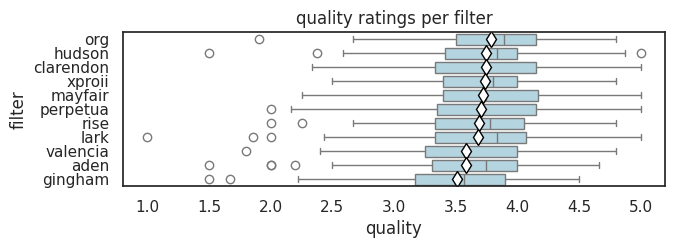

In [43]:
sns.set(rc={'figure.figsize':(7,2)})
sns.set_style("white")
ax = sns.boxplot(
    x="rating", y="filter", data=dmean_iq,
    order=dmean_iq[["filter", "rating"]].groupby(by=['filter']).mean().sort_values(by="rating", ascending=False).index,
    showmeans=True, meanprops={'marker':'d','markerfacecolor':'white','markeredgecolor':'black','markersize':'8'},
    color="lightblue"
)
ax.set_xlabel("quality")
ax.set_xlim(0.8,5.2)
ax.set_title("quality ratings per filter")
# TODO export this figure + color it

ax.get_figure().savefig("filter_quality.pdf", bbox_inches='tight')

In [44]:
dmean_iq

,stimuli_file,rating,filter,base_img
0,./stimuli/aden_01_IMG_9832.jpg,3.900000,aden,01_IMG_9832.jpg
1,./stimuli/aden_02_IMG_0047.jpg,3.750000,aden,02_IMG_0047.jpg
2,./stimuli/aden_IMG_1665.jpg,3.800000,aden,IMG_1665.jpg
3,./stimuli/aden_IMG_3867_4.jpg,3.166667,aden,IMG_3867_4.jpg
4,./stimuli/aden_IMG_3995.jpg,3.000000,aden,IMG_3995.jpg
...,...,...,...,...
1084,./stimuli/xproii_p50.jpg,3.500000,xproii,p50.jpg
1085,./stimuli/xproii_p51.jpg,3.833333,xproii,p51.jpg
1086,./stimuli/xproii_p52.jpg,2.857143,xproii,p52.jpg
1087,./stimuli/xproii_p53.jpg,4.000000,xproii,p53.jpg


mean quality rating: mean_quality=np.float64(3.68)
std appeal rating: std_quality=np.float64(0.57)


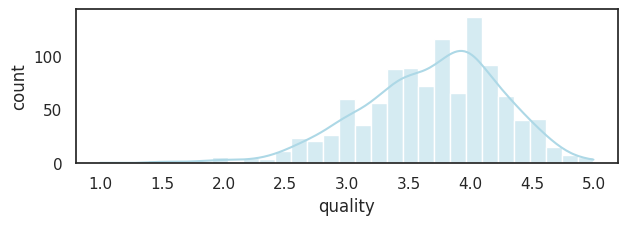

In [45]:
ax = sns.histplot(dmean_iq["rating"], kde=True, color="lightblue")
ax.set_xlabel("quality")
ax.set_ylabel("count")
ax.set_xlim(0.8,5.2)
ax.get_figure().savefig("dist_quality.pdf", bbox_inches='tight')

mean_quality = dmean_iq["rating"].mean().round(2)
print(f"mean quality rating: {mean_quality=}")

std_quality = dmean_iq["rating"].std().round(2)

print(f"std appeal rating: {std_quality=}")



In [46]:
dmean_iq.sort_values(by="rating", ascending=False).head(5)

,stimuli_file,rating,filter,base_img
436,./stimuli/lark_IMG_7663.jpg,5.0,lark,IMG_7663.jpg
148,./stimuli/clarendon_p05.jpg,5.0,clarendon,p05.jpg
540,./stimuli/mayfair_p01.jpg,5.0,mayfair,p01.jpg
357,./stimuli/hudson_p16.jpg,5.0,hudson,p16.jpg
753,./stimuli/perpetua_p16.jpg,5.0,perpetua,p16.jpg


In [47]:
dmean_iq.sort_values(by="rating", ascending=False).tail(5)

,stimuli_file,rating,filter,base_img
257,./stimuli/gingham_p15.jpg,1.666667,gingham,p15.jpg
42,./stimuli/aden_IMG_7758.jpg,1.500000,aden,IMG_7758.jpg
240,./stimuli/gingham_IMG_7758.jpg,1.500000,gingham,IMG_7758.jpg
310,./stimuli/hudson_IMG_5150.jpg,1.500000,hudson,IMG_5150.jpg
446,./stimuli/lark_p06.jpg,1.000000,lark,p06.jpg


In [48]:
# image realism

dre = dr[dr["rating_type"] == "range_realism"].copy()
dre["filter"] = dre["stimuli_file"].apply(lambda x: os.path.basename(x).split("_")[0])
dre["filter"] = dre["filter"].apply(lambda x: "org" if x == "normal" else x)
dre["base_img"] = dre["stimuli_file"].apply(lambda x: "_".join(os.path.basename(x).split("_")[1:]))
dre["rating"] = dre["rating"].apply(lambda x: int(x))
dre

,user_ID,stimuli_ID,stimuli_file,rating_type,rating,timestamp,valid,filter,base_img
3,1,536,./stimuli/mayfair_IMG_7753.jpg,range_realism,2,2026-01-12 15:40:07 802754,True,mayfair,IMG_7753.jpg
12,1,268,./stimuli/gingham_p26.jpg,range_realism,4,2026-01-12 15:40:18 116008,True,gingham,p26.jpg
21,1,378,./stimuli/hudson_p37.jpg,range_realism,5,2026-01-12 15:40:27 246443,True,hudson,p37.jpg
30,1,719,./stimuli/perpetua_IMG_6255_.jpg,range_realism,4,2026-01-12 15:40:36 695706,True,perpetua,IMG_6255_.jpg
39,1,338,./stimuli/hudson_IMG_7753.jpg,range_realism,2,2026-01-12 15:40:46 593200,True,hudson,IMG_7753.jpg
...,...,...,...,...,...,...,...,...,...
70134,36,1014,./stimuli/xproii_IMG_6010.jpg,range_realism,5,2026-01-15 11:31:35 521731,True,xproii,IMG_6010.jpg
70143,36,205,./stimuli/gingham_IMG_4436.jpg,range_realism,5,2026-01-15 11:31:44 265739,True,gingham,IMG_4436.jpg
70152,36,995,./stimuli/xproii_IMG_4140.jpg,range_realism,5,2026-01-15 11:31:58 875267,True,xproii,IMG_4140.jpg
70161,36,298,./stimuli/hudson_02_IMG_0047.jpg,range_realism,4,2026-01-15 11:32:11 910335,True,hudson,02_IMG_0047.jpg


In [49]:
dmean_ir = dre[["stimuli_file", "rating"]].groupby(by=["stimuli_file"]).mean().reset_index()
dmean_ir

,stimuli_file,rating
0,./stimuli/aden_01_IMG_9832.jpg,4.200000
1,./stimuli/aden_02_IMG_0047.jpg,4.125000
2,./stimuli/aden_IMG_1665.jpg,4.200000
3,./stimuli/aden_IMG_3867_4.jpg,3.500000
4,./stimuli/aden_IMG_3995.jpg,3.200000
...,...,...
1084,./stimuli/xproii_p50.jpg,4.000000
1085,./stimuli/xproii_p51.jpg,3.500000
1086,./stimuli/xproii_p52.jpg,3.428571
1087,./stimuli/xproii_p53.jpg,2.500000


In [50]:
dmean_ir["filter"] = dmean_ir["stimuli_file"].apply(lambda x: os.path.basename(x).split("_")[0])
dmean_ir["filter"] = dmean_ir["filter"].apply(lambda x: "org" if x == "normal" else x)
dmean_ir["base_img"] = dmean_ir["stimuli_file"].apply(lambda x: "_".join(os.path.basename(x).split("_")[1:]))

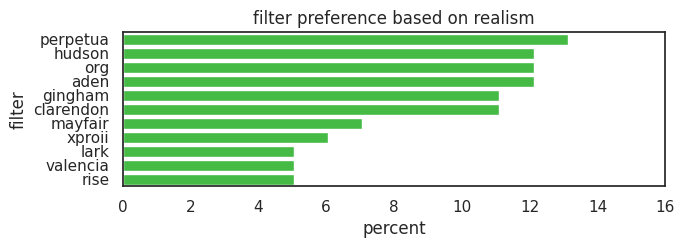

In [51]:
maxrating_per_image = dmean_ir.groupby(by="base_img").apply(lambda x: x[x['rating'] == x['rating'].max()].head(1), include_groups=False).reset_index(drop=True)

sns.set(rc={'figure.figsize':(7,2)})
sns.set_style("white")
ax = sns.countplot(
    y="filter", 
    data=maxrating_per_image, 
    stat="percent",
    order=maxrating_per_image['filter'].value_counts().index,
    color="limegreen"
)
ax.set_xlim(0,16)
ax.set_title("filter preference based on realism")

ax.get_figure().savefig("filter_realism_pref.pdf", bbox_inches='tight')

In [52]:
maxrating_per_image["rating_type"] = "realism"
maxrating_per_image

,stimuli_file,rating,filter,rating_type
0,./stimuli/gingham_01_IMG_9832.jpg,4.300000,gingham,realism
1,./stimuli/perpetua_02_IMG_0047.jpg,4.500000,perpetua,realism
2,./stimuli/perpetua_IMG_1665.jpg,4.600000,perpetua,realism
3,./stimuli/hudson_IMG_3867_4.jpg,4.000000,hudson,realism
4,./stimuli/normal_IMG_3995.jpg,3.500000,org,realism
...,...,...,...,...
94,./stimuli/gingham_p50.jpg,4.714286,gingham,realism
95,./stimuli/aden_p51.jpg,4.500000,aden,realism
96,./stimuli/gingham_p52.jpg,4.285714,gingham,realism
97,./stimuli/valencia_p53.jpg,5.000000,valencia,realism


In [53]:
pref = pd.concat([pref, maxrating_per_image], ignore_index=True)
pref

,stimuli_file,rating,filter,rating_type
0,./stimuli/hudson_01_IMG_9832.jpg,4.285714,hudson,appeal
1,./stimuli/hudson_02_IMG_0047.jpg,4.333333,hudson,appeal
2,./stimuli/valencia_IMG_1665.jpg,4.250000,valencia,appeal
3,./stimuli/rise_IMG_3867_4.jpg,4.250000,rise,appeal
4,./stimuli/rise_IMG_3995.jpg,4.000000,rise,appeal
...,...,...,...,...
292,./stimuli/gingham_p50.jpg,4.714286,gingham,realism
293,./stimuli/aden_p51.jpg,4.500000,aden,realism
294,./stimuli/gingham_p52.jpg,4.285714,gingham,realism
295,./stimuli/valencia_p53.jpg,5.000000,valencia,realism


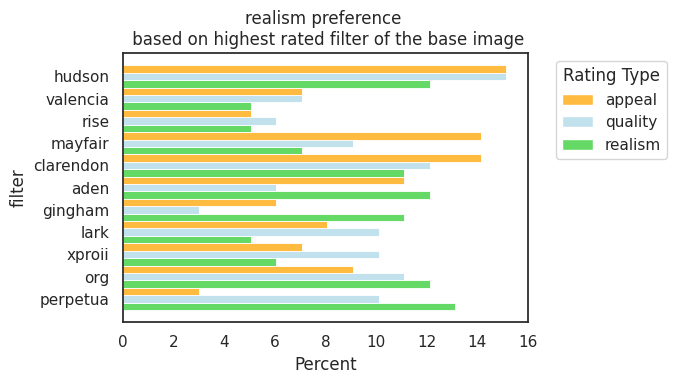

In [54]:
sns.set(rc={'figure.figsize':(7,4)})
sns.set_style("white")
ax = sns.histplot(
    y="filter", 
    hue="rating_type",
    data=pref, 
    stat="percent",
    common_norm=False,
    multiple="dodge",
    palette = {"realism": "limegreen", "appeal": "orange", "quality": "lightblue"},
    legend=True
    #order=maxrating_per_image['filter'].value_counts().index,
    #color="limegreen"
)
#ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='')
ax.set_xlim(0,16)
ax.set_title("realism preference \n based on highest rated filter of the base image")

ax.legend_.set_title('Rating Type')
ax.legend_.set_bbox_to_anchor((1.05, 1))
    
plt.tight_layout()
plt.show()


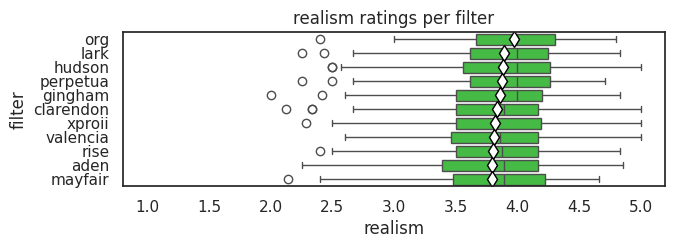

In [55]:
sns.set(rc={'figure.figsize':(7,2)})
sns.set_style("white")
ax = sns.boxplot(
    x="rating", y="filter", data=dmean_ir,
    order=dmean_ir[["filter", "rating"]].groupby(by=['filter']).mean().sort_values(by="rating", ascending=False).index,
    showmeans=True, meanprops={'marker':'d','markerfacecolor':'white','markeredgecolor':'black','markersize':'8'},
    color="limegreen"
)
ax.set_xlabel("realism")
ax.set_xlim(0.8,5.2)
ax.set_title("realism ratings per filter")
# TODO export this figure + color it

ax.get_figure().savefig("filter_realism.pdf", bbox_inches='tight')

3.85
0.52


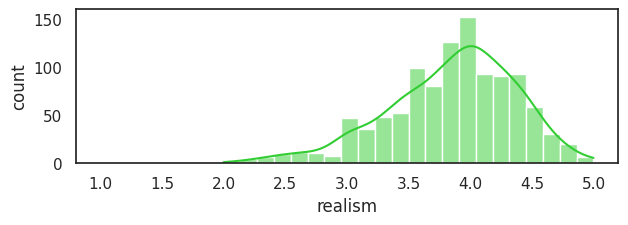

In [56]:
ax = sns.histplot(dmean_ir["rating"], kde=True, color="limegreen")
ax.set_xlabel("realism")
ax.set_ylabel("count")
ax.set_xlim(0.8,5.2)
ax.get_figure().savefig("dist_realism.pdf", bbox_inches='tight')

print(dmean_ir["rating"].mean().round(2))
print(dmean_ir["rating"].std().round(2))

In [57]:
# one distplot?

all_in_one = dmean_ir.copy() 
all_in_one["rating_type"] = "realism"

tmp = dmean_iq.copy()
tmp["rating_type"] = "quality"

all_in_one = pd.concat([all_in_one, tmp], ignore_index=True)

tmp = dmean_ia.copy()
tmp["rating_type"] = "appeal"

all_in_one = pd.concat([all_in_one, tmp], ignore_index=True)


all_in_one

,stimuli_file,rating,filter,base_img,rating_type
0,./stimuli/aden_01_IMG_9832.jpg,4.200000,aden,01_IMG_9832.jpg,realism
1,./stimuli/aden_02_IMG_0047.jpg,4.125000,aden,02_IMG_0047.jpg,realism
2,./stimuli/aden_IMG_1665.jpg,4.200000,aden,IMG_1665.jpg,realism
3,./stimuli/aden_IMG_3867_4.jpg,3.500000,aden,IMG_3867_4.jpg,realism
4,./stimuli/aden_IMG_3995.jpg,3.200000,aden,IMG_3995.jpg,realism
...,...,...,...,...,...
3262,./stimuli/xproii_p50.jpg,3.250000,xproii,p50.jpg,appeal
3263,./stimuli/xproii_p51.jpg,4.166667,xproii,p51.jpg,appeal
3264,./stimuli/xproii_p52.jpg,3.142857,xproii,p52.jpg,appeal
3265,./stimuli/xproii_p53.jpg,4.000000,xproii,p53.jpg,appeal


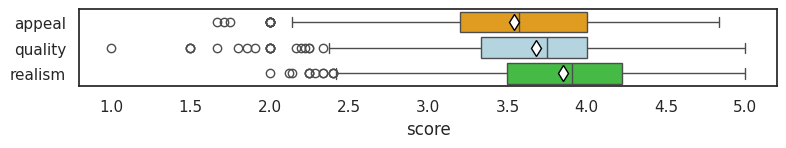

In [58]:
sns.set(rc={'figure.figsize':(9,1)})
sns.set_style("white")
ax = sns.boxplot(
    x="rating", hue="rating_type", y="rating_type",
    data=all_in_one, color="limegreen", order=["appeal", "quality", "realism"],
    palette= {"realism": "limegreen", "appeal": "orange", "quality": "lightblue"},
    showmeans=True, meanprops={'marker':'d','markerfacecolor':'white','markeredgecolor':'black','markersize':'8'}
    
)
ax.set_xlim(0.8,5.2)
ax.set_ylabel("")
ax.set_xlabel("score")

ax.get_figure().savefig("dist_all.pdf", bbox_inches='tight')

In [59]:
sel = all_in_one[all_in_one["rating_type"] == "appeal"].copy()
xx = sel[sel["filter"]=="org"].sort_values(by="rating")
xx["rank"] = range(len(xx))
xx

,stimuli_file,rating,filter,base_img,rating_type,rank
2785,./stimuli/normal_IMG_5150.jpg,2.181818,org,IMG_5150.jpg,appeal,0
2833,./stimuli/normal_p17.jpg,2.333333,org,p17.jpg,appeal,1
2788,./stimuli/normal_IMG_5424.jpg,2.375000,org,IMG_5424.jpg,appeal,2
2843,./stimuli/normal_p27.jpg,2.571429,org,p27.jpg,appeal,3
2775,./stimuli/normal_IMG_3867_4.jpg,2.600000,org,IMG_3867_4.jpg,appeal,4
...,...,...,...,...,...,...
2818,./stimuli/normal_p02.jpg,4.454545,org,p02.jpg,appeal,94
2801,./stimuli/normal_IMG_6457.jpg,4.500000,org,IMG_6457.jpg,appeal,95
2837,./stimuli/normal_p21.jpg,4.500000,org,p21.jpg,appeal,96
2852,./stimuli/normal_p36.jpg,4.571429,org,p36.jpg,appeal,97


In [60]:
xx[xx["base_img"] == "IMG_5150.jpg"]

,stimuli_file,rating,filter,base_img,rating_type,rank
2785,./stimuli/normal_IMG_5150.jpg,2.181818,org,IMG_5150.jpg,appeal,0


In [61]:
xx[xx["base_img"] == "01_IMG_9832.jpg"]

,stimuli_file,rating,filter,base_img,rating_type,rank
2772,./stimuli/normal_01_IMG_9832.jpg,4.111111,org,01_IMG_9832.jpg,appeal,81


In [62]:
xx[xx["base_img"] == "p51.jpg"]

,stimuli_file,rating,filter,base_img,rating_type,rank
2867,./stimuli/normal_p51.jpg,4.428571,org,p51.jpg,appeal,92


In [63]:
sel[sel["base_img"] == "IMG_5150.jpg"].sort_values(by="rating")

,stimuli_file,rating,filter,base_img,rating_type
2488,./stimuli/hudson_IMG_5150.jpg,1.666667,hudson,IMG_5150.jpg,appeal
2884,./stimuli/perpetua_IMG_5150.jpg,2.000000,perpetua,IMG_5150.jpg,appeal
2785,./stimuli/normal_IMG_5150.jpg,2.181818,org,IMG_5150.jpg,appeal
2983,./stimuli/rise_IMG_5150.jpg,2.333333,rise,IMG_5150.jpg,appeal
3181,./stimuli/xproii_IMG_5150.jpg,2.400000,xproii,IMG_5150.jpg,appeal
2389,./stimuli/gingham_IMG_5150.jpg,2.400000,gingham,IMG_5150.jpg,appeal
2686,./stimuli/mayfair_IMG_5150.jpg,2.500000,mayfair,IMG_5150.jpg,appeal
2587,./stimuli/lark_IMG_5150.jpg,2.500000,lark,IMG_5150.jpg,appeal
3082,./stimuli/valencia_IMG_5150.jpg,2.600000,valencia,IMG_5150.jpg,appeal
2191,./stimuli/aden_IMG_5150.jpg,2.600000,aden,IMG_5150.jpg,appeal


In [64]:
all_in_one

,stimuli_file,rating,filter,base_img,rating_type
0,./stimuli/aden_01_IMG_9832.jpg,4.200000,aden,01_IMG_9832.jpg,realism
1,./stimuli/aden_02_IMG_0047.jpg,4.125000,aden,02_IMG_0047.jpg,realism
2,./stimuli/aden_IMG_1665.jpg,4.200000,aden,IMG_1665.jpg,realism
3,./stimuli/aden_IMG_3867_4.jpg,3.500000,aden,IMG_3867_4.jpg,realism
4,./stimuli/aden_IMG_3995.jpg,3.200000,aden,IMG_3995.jpg,realism
...,...,...,...,...,...
3262,./stimuli/xproii_p50.jpg,3.250000,xproii,p50.jpg,appeal
3263,./stimuli/xproii_p51.jpg,4.166667,xproii,p51.jpg,appeal
3264,./stimuli/xproii_p52.jpg,3.142857,xproii,p52.jpg,appeal
3265,./stimuli/xproii_p53.jpg,4.000000,xproii,p53.jpg,appeal


In [65]:
all_in_one

,stimuli_file,rating,filter,base_img,rating_type
0,./stimuli/aden_01_IMG_9832.jpg,4.200000,aden,01_IMG_9832.jpg,realism
1,./stimuli/aden_02_IMG_0047.jpg,4.125000,aden,02_IMG_0047.jpg,realism
2,./stimuli/aden_IMG_1665.jpg,4.200000,aden,IMG_1665.jpg,realism
3,./stimuli/aden_IMG_3867_4.jpg,3.500000,aden,IMG_3867_4.jpg,realism
4,./stimuli/aden_IMG_3995.jpg,3.200000,aden,IMG_3995.jpg,realism
...,...,...,...,...,...
3262,./stimuli/xproii_p50.jpg,3.250000,xproii,p50.jpg,appeal
3263,./stimuli/xproii_p51.jpg,4.166667,xproii,p51.jpg,appeal
3264,./stimuli/xproii_p52.jpg,3.142857,xproii,p52.jpg,appeal
3265,./stimuli/xproii_p53.jpg,4.000000,xproii,p53.jpg,appeal


In [66]:
all_in_one.to_csv("all_in_one.csv", index=False)

In [67]:

res = pd.DataFrame()
for rt, _sel in all_in_one.groupby(by="rating_type"):
    deltas = []
    for l, g in _sel.groupby(by="base_img"):
        org = g[g["filter"] == "org"]["rating"]
        maxx = g.sort_values(by="rating")["rating"].values[-1]
        deltas.append(float(maxx -org))
    ddelta = pd.DataFrame({"diff": deltas})
    ddelta["rating_type"] = rt
    res = pd.concat([res,ddelta], ignore_index=True)
res

/tmp/ipykernel_1030646/1346135718.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  deltas.append(float(maxx -org))
/tmp/ipykernel_1030646/1346135718.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  deltas.append(float(maxx -org))
/tmp/ipykernel_1030646/1346135718.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  deltas.append(float(maxx -org))


,diff,rating_type
0,0.174603,appeal
1,0.583333,appeal
2,0.150000,appeal
3,1.650000,appeal
4,0.500000,appeal
...,...,...
292,0.714286,realism
293,0.642857,realism
294,1.285714,realism
295,1.583333,realism


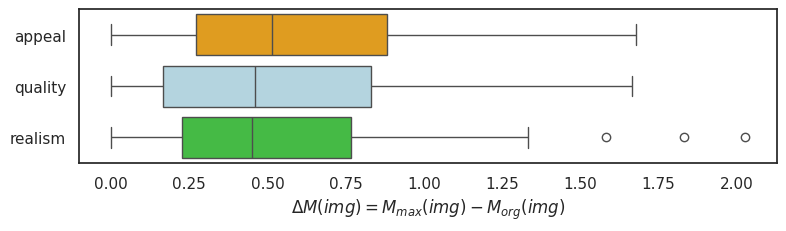

In [68]:
sns.set(rc={'figure.figsize':(9,2)})
sns.set_style("white")
ax = sns.boxplot(
    x="diff",
    y="rating_type",
    hue="rating_type",
    data=res,
    palette= {"realism": "limegreen", "appeal": "orange", "quality": "lightblue"},

) #, stat="percent")



    
#ax.legend_.set_bbox_to_anchor((1.05, 1))

ax.set_ylabel("")
ax.set_xlabel(r"$\Delta M(img) = M_{max}(img) - M_{org}(img)$")  

ax.get_figure().savefig("delta_appeal.pdf", bbox_inches='tight')

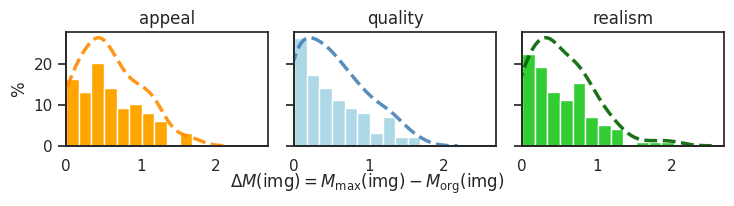

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

# displot creates a grid of histograms
g = sns.displot(
    data=res,
    x="diff",
    hue="rating_type",  # Color by rating_type
    col="rating_type",  # Separate panels by rating_type
    stat="percent",
    #col_wrap=1,
    kind="hist",
    palette={"realism": "limegreen", "appeal": "orange", "quality": "lightblue"},
    kde=False,
    height=2,
    aspect=1.25,
    alpha=1, # edgecolor='black',
    common_norm=False, legend=False
)

darker_colors = {
    'realism': 'darkgreen',
    'appeal': 'darkorange',
    'quality': 'steelblue'
}

# Add custom KDE lines with darker colors
for rating, ax in zip(["appeal", 'quality', 'realism'], g.axes.flat):
    subset = res[res['rating_type'] == rating]
    
    # Create second axis for KDE (shares x-axis)
    ax2 = ax.twinx()
    
    # Plot KDE on the second axis
    sns.kdeplot(
        data=subset,
        x="diff",
        color=darker_colors[rating],
        linewidth=2.5,
        linestyle='--',
        ax=ax2,
        alpha=0.9
    )
    
    # Hide the right y-axis labels
    ax2.set_ylabel('')
    ax2.tick_params(right=False, labelright=False)
    ax2.set_xlim(0,2.7)
    
                
# Adjust the plot
g.set_axis_labels("", "%")
g.set_xlabels(r"$\Delta M(img) = M_{max}(img) - M_{org}(img)$", fontsize=11)

for ax in g.axes.flat:
    ax.set_xlabel('')

g.fig.text(0.5, 0.02,  # x, y position in figure coordinates
           r"$\Delta M(\text{img}) = M_{\max}(\text{img}) - M_{\text{org}}(\text{img})$",
           ha='center')
g.set_titles(col_template="{col_name}")

plt.tight_layout()
plt.savefig("delta_appeal_ext.pdf", bbox_inches='tight')
plt.show()



In [70]:
ddt = dmean_ir.rename(columns={"rating": "realism"})
ddt = pd.merge(dmean_iq.rename(columns={"rating": "quality"}), ddt)
ddt = pd.merge(dmean_ia.rename(columns={"rating": "appeal"}), ddt)
ddt

,stimuli_file,appeal,filter,base_img,quality,realism
0,./stimuli/aden_01_IMG_9832.jpg,3.800000,aden,01_IMG_9832.jpg,3.900000,4.200000
1,./stimuli/aden_02_IMG_0047.jpg,2.875000,aden,02_IMG_0047.jpg,3.750000,4.125000
2,./stimuli/aden_IMG_1665.jpg,4.200000,aden,IMG_1665.jpg,3.800000,4.200000
3,./stimuli/aden_IMG_3867_4.jpg,2.666667,aden,IMG_3867_4.jpg,3.166667,3.500000
4,./stimuli/aden_IMG_3995.jpg,2.800000,aden,IMG_3995.jpg,3.000000,3.200000
...,...,...,...,...,...,...
1084,./stimuli/xproii_p50.jpg,3.250000,xproii,p50.jpg,3.500000,4.000000
1085,./stimuli/xproii_p51.jpg,4.166667,xproii,p51.jpg,3.833333,3.500000
1086,./stimuli/xproii_p52.jpg,3.142857,xproii,p52.jpg,2.857143,3.428571
1087,./stimuli/xproii_p53.jpg,4.000000,xproii,p53.jpg,4.000000,2.500000


In [71]:
ddt = dmean_ir.rename(columns={"rating": "realism"})
ddt = pd.merge(dmean_iq.rename(columns={"rating": "quality"}), ddt)
ddt = pd.merge(dmean_ia.rename(columns={"rating": "appeal"}), ddt)
ddt


,stimuli_file,appeal,filter,base_img,quality,realism
0,./stimuli/aden_01_IMG_9832.jpg,3.800000,aden,01_IMG_9832.jpg,3.900000,4.200000
1,./stimuli/aden_02_IMG_0047.jpg,2.875000,aden,02_IMG_0047.jpg,3.750000,4.125000
2,./stimuli/aden_IMG_1665.jpg,4.200000,aden,IMG_1665.jpg,3.800000,4.200000
3,./stimuli/aden_IMG_3867_4.jpg,2.666667,aden,IMG_3867_4.jpg,3.166667,3.500000
4,./stimuli/aden_IMG_3995.jpg,2.800000,aden,IMG_3995.jpg,3.000000,3.200000
...,...,...,...,...,...,...
1084,./stimuli/xproii_p50.jpg,3.250000,xproii,p50.jpg,3.500000,4.000000
1085,./stimuli/xproii_p51.jpg,4.166667,xproii,p51.jpg,3.833333,3.500000
1086,./stimuli/xproii_p52.jpg,3.142857,xproii,p52.jpg,2.857143,3.428571
1087,./stimuli/xproii_p53.jpg,4.000000,xproii,p53.jpg,4.000000,2.500000


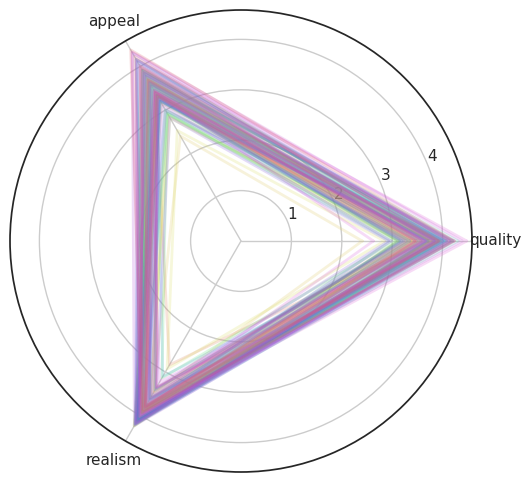

In [72]:
import matplotlib.pyplot as plt
import numpy as np

# Daten definieren
categories = ['quality', 'appeal', 'realism']
values = [4, 3, 5]

# Winkel berechnen (Kreis in Segmente unterteilen)
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()

# Plot schließen: Ersten Wert und Winkel ans Ende anfügen
values += values[:1]
angles += angles[:1]

# Plot erstellen
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

cp = sns.color_palette("hls", 100)
i = 0
for l, g in ddt.groupby(by="base_img"):
    values = [g["quality"].mean(), g["appeal"].mean(), g["realism"].mean()]
    values += values[:1]
    #ax.fill(angles, values, color='red', alpha=0.01) # Fläche füllen
    ax.plot(angles, values, color=cp[i], linewidth=2, alpha=0.21) # Umriss
    #break
    i += 1
    

# Achsenbeschriftung
#ax.set_yticklabels([]) # Optionale Skala ausblenden
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

plt.show()

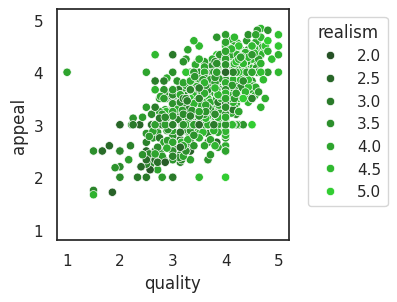

In [73]:
import matplotlib.pyplot as plt
sns.set(rc={'figure.figsize':(3,3)})
sns.set_style("white")

ax = sns.scatterplot(data=ddt, x='quality', y='appeal', hue='realism', hue_norm=(1,5), legend="brief", palette=sns.dark_palette("limegreen", as_cmap=True))
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='realism')

ax.set_xlim(0.8,5.2)
ax.set_ylim(0.8,5.2)
ax.get_figure().savefig("q_a.pdf", bbox_inches='tight')

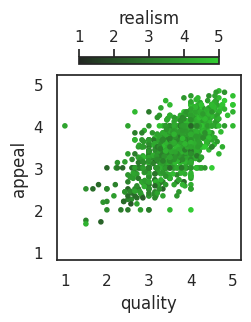

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.colors import Normalize

# Create figure and axis
fig, ax = plt.subplots(figsize=(3, 3))
sns.set_style("white")

# Define normalization and colormap
norm = Normalize(vmin=1, vmax=5)
cmap = sns.dark_palette("limegreen", as_cmap=True)

sc = ax.scatter(
    data=ddt, 
    x='quality', 
    y='appeal', 
    c='realism',     
    norm=norm, 
    cmap=cmap,
    marker="."
)
ax.set_ylabel("appeal")
ax.set_xlabel("quality")
ax.set_aspect(1)
ax.set_xlim(0.8,5.2)
ax.set_ylim(0.8,5.2)


ax.set_xticks([1, 2, 3, 4, 5], [1, 2, 3, 4, 5])
ax.set_yticks([1, 2, 3, 4, 5], [1, 2, 3, 4, 5])

# Add a colorbar with ticks from 1 to 5
cbar = fig.colorbar(sc, ax=ax, label='realism', ticks=[1, 2, 3, 4, 5], shrink=0.6, location='top')

fig.savefig("q_a.pdf", bbox_inches='tight')


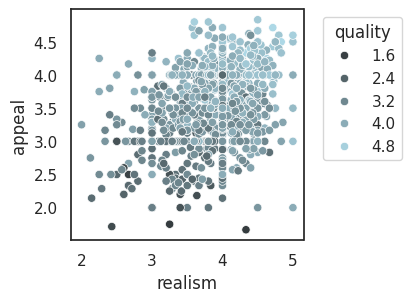

In [75]:
ax = sns.scatterplot(data=ddt, x='realism', y='appeal', hue='quality', palette=sns.dark_palette("lightblue", as_cmap=True))
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='quality')
ax.get_figure().savefig("r_a.pdf", bbox_inches='tight')

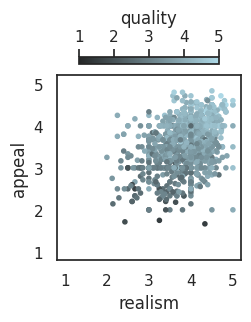

In [76]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(3, 3))
sns.set_style("white")

# Define normalization and colormap
norm = Normalize(vmin=1, vmax=5)
cmap = sns.dark_palette("lightblue", as_cmap=True)

sc = ax.scatter(
    data=ddt, 
    x='realism', 
    y='appeal', 
    c='quality',     
    norm=norm, 
    cmap=cmap,
    marker="."
)
ax.set_ylabel("appeal")
ax.set_xlabel("realism")
ax.set_aspect(1)
ax.set_xlim(0.8,5.2)
ax.set_ylim(0.8,5.2)

ax.set_xticks([1, 2, 3, 4, 5], [1, 2, 3, 4, 5])
ax.set_yticks([1, 2, 3, 4, 5], [1, 2, 3, 4, 5])

# Add a colorbar with ticks from 1 to 5
cbar = fig.colorbar(sc, ax=ax, label='quality', ticks=[1, 2, 3, 4, 5], shrink=0.6, location='top')

fig.savefig("r_a.pdf", bbox_inches='tight')

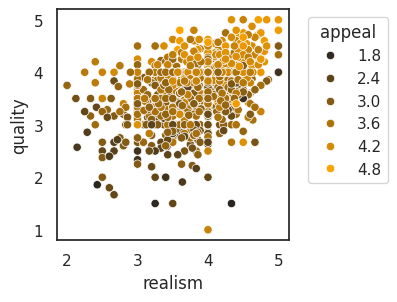

In [77]:
ax = sns.scatterplot(data=ddt, x='realism', y='quality', hue='appeal', palette=sns.dark_palette("orange", as_cmap=True))
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='appeal')
ax.get_figure().savefig("r_q.pdf", bbox_inches='tight')

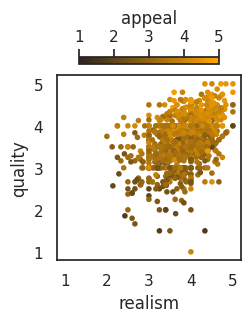

In [78]:
fig, ax = plt.subplots(figsize=(3, 3))
sns.set_style("white")

# Define normalization and colormap
norm = Normalize(vmin=1, vmax=5)
cmap = sns.dark_palette("orange", as_cmap=True)

sc = ax.scatter(
    data=ddt, 
    x='realism', 
    y='quality', 
    c='appeal',     
    norm=norm, 
    cmap=cmap,
    marker="."
)
ax.set_ylabel("quality")
ax.set_xlabel("realism")
ax.set_aspect(1)
ax.set_xlim(0.8,5.2)
ax.set_ylim(0.8,5.2)

ax.set_xticks([1, 2, 3, 4, 5], [1, 2, 3, 4, 5])
ax.set_yticks([1, 2, 3, 4, 5], [1, 2, 3, 4, 5])

# Add a colorbar with ticks from 1 to 5
cbar = fig.colorbar(sc, ax=ax, label='appeal', ticks=[1, 2, 3, 4, 5], shrink=0.6, location='top')

fig.savefig("r_q.pdf", bbox_inches='tight')

In [79]:
# correlations
import itertools
aspects = ["quality", "appeal", "realism"]

values = []
for (a, b) in itertools.combinations(aspects, 2):
    print(a,b)
    values.append({
            "p": ddt[[a,b]].corr(method="pearson")[a].values[-1],
            "k": ddt[[a,b]].corr(method="kendall")[a].values[-1],
            "s": ddt[[a,b]].corr(method="spearman")[a].values[-1],
            "vs": a + " vs. " + b
        }
    )

quality appeal
quality realism
appeal realism


In [80]:
values

[{'p': np.float64(0.6628751238982222),
  'k': np.float64(0.4811765319539594),
  's': np.float64(0.6437413279252759),
  'vs': 'quality vs. appeal'},
 {'p': np.float64(0.43454985097026755),
  'k': np.float64(0.30081271005835686),
  's': np.float64(0.4266617382829562),
  'vs': 'quality vs. realism'},
 {'p': np.float64(0.3569565209579143),
  'k': np.float64(0.23471878117809092),
  's': np.float64(0.33248937674302376),
  'vs': 'appeal vs. realism'}]

In [81]:
dm = pd.DataFrame(values).round(3)
dm

,p,k,s,vs
0,0.663,0.481,0.644,quality vs. appeal
1,0.435,0.301,0.427,quality vs. realism
2,0.357,0.235,0.332,appeal vs. realism


In [82]:
print(dm[["vs", "p", "k", "s"]].sort_values(by="p", ascending=False).to_latex(float_format=lambda x: '%.3f' % x, index=False))

\begin{tabular}{lrrr}
\toprule
vs & p & k & s \\
\midrule
quality vs. appeal & 0.663 & 0.481 & 0.644 \\
quality vs. realism & 0.435 & 0.301 & 0.427 \\
appeal vs. realism & 0.357 & 0.235 & 0.332 \\
\bottomrule
\end{tabular}



In [83]:
ddt["combined"] = np.sqrt(ddt["appeal"]**2 +  ddt["quality"]**2 +  ddt["realism"]**2)
ddt

,stimuli_file,appeal,filter,base_img,quality,realism,combined
0,./stimuli/aden_01_IMG_9832.jpg,3.800000,aden,01_IMG_9832.jpg,3.900000,4.200000,6.876772
1,./stimuli/aden_02_IMG_0047.jpg,2.875000,aden,02_IMG_0047.jpg,3.750000,4.125000,6.272460
2,./stimuli/aden_IMG_1665.jpg,4.200000,aden,IMG_1665.jpg,3.800000,4.200000,7.051241
3,./stimuli/aden_IMG_3867_4.jpg,2.666667,aden,IMG_3867_4.jpg,3.166667,3.500000,5.421152
4,./stimuli/aden_IMG_3995.jpg,2.800000,aden,IMG_3995.jpg,3.000000,3.200000,5.203845
...,...,...,...,...,...,...,...
1084,./stimuli/xproii_p50.jpg,3.250000,xproii,p50.jpg,3.500000,4.000000,6.229968
1085,./stimuli/xproii_p51.jpg,4.166667,xproii,p51.jpg,3.833333,3.500000,6.656242
1086,./stimuli/xproii_p52.jpg,3.142857,xproii,p52.jpg,2.857143,3.428571,5.458564
1087,./stimuli/xproii_p53.jpg,4.000000,xproii,p53.jpg,4.000000,2.500000,6.184658


6.42
8.38


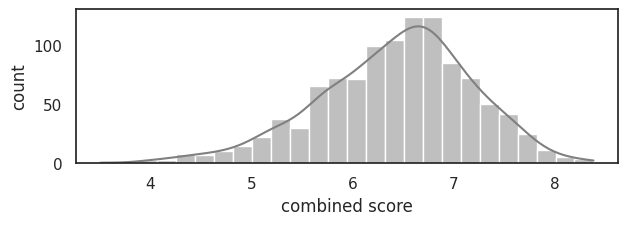

In [84]:
sns.set(rc={'figure.figsize':(7,2)})
sns.set_style("white")

ax = sns.histplot(ddt["combined"], kde=True, color="gray")
ax.set_xlabel("combined score")
ax.set_ylabel("count")
ax.get_figure().savefig("dist_combined.pdf", bbox_inches='tight')

print(ddt["combined"].mean().round(2))
print(ddt["combined"].max().round(2))

In [85]:
drmax = pd.DataFrame()
for l, g in ddt.groupby(by="filter"):
    drmax = pd.concat([g[g["combined"] == g["combined"].max()][["stimuli_file", "combined"]], drmax], ignore_index=True)
    #break
drmax

,stimuli_file,combined
0,./stimuli/xproii_p54.jpg,8.318654
1,./stimuli/valencia_p36.jpg,7.987838
2,./stimuli/rise_p16.jpg,7.898664
3,./stimuli/perpetua_p16.jpg,7.826238
4,./stimuli/normal_p21.jpg,8.085481
5,./stimuli/mayfair_p01.jpg,7.909207
6,./stimuli/lark_IMG_7663.jpg,8.283182
7,./stimuli/hudson_p16.jpg,8.333605
8,./stimuli/gingham_p33.jpg,7.726780
9,./stimuli/clarendon_p05.jpg,8.381527


In [86]:
print("\n".join(drmax["stimuli_file"].values))

./stimuli/xproii_p54.jpg
./stimuli/valencia_p36.jpg
./stimuli/rise_p16.jpg
./stimuli/perpetua_p16.jpg
./stimuli/normal_p21.jpg
./stimuli/mayfair_p01.jpg
./stimuli/lark_IMG_7663.jpg
./stimuli/hudson_p16.jpg
./stimuli/gingham_p33.jpg
./stimuli/clarendon_p05.jpg
./stimuli/aden_p51.jpg


In [87]:
drmin = pd.DataFrame()
for l, g in ddt.groupby(by="filter"):
    drmin = pd.concat([g[g["combined"] == g["combined"].min()][["stimuli_file", "combined"]], drmin], ignore_index=True)
    #break
drmin

,stimuli_file,combined
0,./stimuli/xproii_IMG_7392_.jpg,4.314191
1,./stimuli/valencia_IMG_5150.jpg,4.093898
2,./stimuli/rise_p45.jpg,4.387482
3,./stimuli/perpetua_p27.jpg,4.336537
4,./stimuli/normal_IMG_5150.jpg,4.650602
5,./stimuli/mayfair_IMG_5424.jpg,3.974408
6,./stimuli/lark_IMG_5424.jpg,3.505098
7,./stimuli/hudson_IMG_5424.jpg,4.570626
8,./stimuli/gingham_p15.jpg,4.017324
9,./stimuli/clarendon_IMG_5424.jpg,4.294700


In [88]:
print("\n".join(drmin["stimuli_file"].values))

./stimuli/xproii_IMG_7392_.jpg
./stimuli/valencia_IMG_5150.jpg
./stimuli/rise_p45.jpg
./stimuli/perpetua_p27.jpg
./stimuli/normal_IMG_5150.jpg
./stimuli/mayfair_IMG_5424.jpg
./stimuli/lark_IMG_5424.jpg
./stimuli/hudson_IMG_5424.jpg
./stimuli/gingham_p15.jpg
./stimuli/clarendon_IMG_5424.jpg
./stimuli/aden_IMG_7758.jpg
